## What are you thinking of focusing on? Focusing on hail damage and the assessment of hail severity 

What makes this hazard or application interesting to explore?
It is important to understand and quantify hail effects in order to protect life and property 

Why might it be useful to quantify threat or impact in this area?
As we enter severe storm season, hail is a particularly damaging threat that we continue to improve our quantitative and qualitative understanding of

- March 10th, 2026 - 12z run of the HRRR
- 48 hour run
- First 24 hours, 395 hail reports, last 24 hours only 8
- 

In [4]:
from herbie import Herbie
from herbie.toolbox import EasyMap, pc
from herbie import paint

import matplotlib.pyplot as plt
import cartopy.crs as ccrs

from herbie import Herbie, FastHerbie
import pandas as pd, numpy as np
import xarray as xr
import dask


In [5]:
run = pd.Timestamp("2026-03-10-12")
H = FastHerbie([run], model="hrrr", product="sfc", fxx=np.arange(0,49,1).tolist(), save_dir='./data/', overwrite=True)
#H = Herbie(
 #   "2021-03-10",
   # model="hrrr",
  #  product="sfc",
   # fxx=12,
#)
#H.inventory()

In [6]:
cape = r":CAPE:255-0 mb above ground:"
H.inventory(cape)

,grib_message,start_byte,end_byte,range,reference_time,valid_time,variable,level,forecast_time,search_this,FILE
0,154,120312707,120896681.0,120312707-120896681,2026-03-10 12:00:00,2026-03-10 12:00:00,CAPE,255-0 mb above ground,anl,:CAPE:255-0 mb above ground:anl,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
1,154,134759907,135283069.0,134759907-135283069,2026-03-10 12:00:00,2026-03-10 13:00:00,CAPE,255-0 mb above ground,1 hour fcst,:CAPE:255-0 mb above ground:1 hour fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
2,157,139327857,139843241.0,139327857-139843241,2026-03-10 12:00:00,2026-03-10 14:00:00,CAPE,255-0 mb above ground,2 hour fcst,:CAPE:255-0 mb above ground:2 hour fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
3,157,142782475,143312426.0,142782475-143312426,2026-03-10 12:00:00,2026-03-10 15:00:00,CAPE,255-0 mb above ground,3 hour fcst,:CAPE:255-0 mb above ground:3 hour fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
4,157,144860492,145416073.0,144860492-145416073,2026-03-10 12:00:00,2026-03-10 16:00:00,CAPE,255-0 mb above ground,4 hour fcst,:CAPE:255-0 mb above ground:4 hour fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
5,157,145556410,146140403.0,145556410-146140403,2026-03-10 12:00:00,2026-03-10 17:00:00,CAPE,255-0 mb above ground,5 hour fcst,:CAPE:255-0 mb above ground:5 hour fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
6,157,146862494,147472683.0,146862494-147472683,2026-03-10 12:00:00,2026-03-10 18:00:00,CAPE,255-0 mb above ground,6 hour fcst,:CAPE:255-0 mb above ground:6 hour fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
7,157,146105576,146738222.0,146105576-146738222,2026-03-10 12:00:00,2026-03-10 19:00:00,CAPE,255-0 mb above ground,7 hour fcst,:CAPE:255-0 mb above ground:7 hour fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
8,157,147682447,148340164.0,147682447-148340164,2026-03-10 12:00:00,2026-03-10 20:00:00,CAPE,255-0 mb above ground,8 hour fcst,:CAPE:255-0 mb above ground:8 hour fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
9,157,147009352,147661102.0,147009352-147661102,2026-03-10 12:00:00,2026-03-10 21:00:00,CAPE,255-0 mb above ground,9 hour fcst,:CAPE:255-0 mb above ground:9 hour fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...


In [7]:
VIL = r":VIL:"
H.inventory(VIL)

,grib_message,start_byte,end_byte,range,reference_time,valid_time,variable,level,forecast_time,search_this,FILE
0,4,924070,1204417.0,924070-1204417,2026-03-10 12:00:00,2026-03-10 12:00:00,VIL,entire atmosphere,anl,:VIL:entire atmosphere:anl,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
1,4,818498,1019824.0,818498-1019824,2026-03-10 12:00:00,2026-03-10 13:00:00,VIL,entire atmosphere,1 hour fcst,:VIL:entire atmosphere:1 hour fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
2,4,1073487,1373060.0,1073487-1373060,2026-03-10 12:00:00,2026-03-10 14:00:00,VIL,entire atmosphere,2 hour fcst,:VIL:entire atmosphere:2 hour fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
3,4,1095328,1375861.0,1095328-1375861,2026-03-10 12:00:00,2026-03-10 15:00:00,VIL,entire atmosphere,3 hour fcst,:VIL:entire atmosphere:3 hour fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
4,4,1256501,1605172.0,1256501-1605172,2026-03-10 12:00:00,2026-03-10 16:00:00,VIL,entire atmosphere,4 hour fcst,:VIL:entire atmosphere:4 hour fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
5,4,1234188,1548835.0,1234188-1548835,2026-03-10 12:00:00,2026-03-10 17:00:00,VIL,entire atmosphere,5 hour fcst,:VIL:entire atmosphere:5 hour fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
6,4,1320851,1656913.0,1320851-1656913,2026-03-10 12:00:00,2026-03-10 18:00:00,VIL,entire atmosphere,6 hour fcst,:VIL:entire atmosphere:6 hour fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
7,4,1402684,1763294.0,1402684-1763294,2026-03-10 12:00:00,2026-03-10 19:00:00,VIL,entire atmosphere,7 hour fcst,:VIL:entire atmosphere:7 hour fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
8,4,1490524,1788676.0,1490524-1788676,2026-03-10 12:00:00,2026-03-10 20:00:00,VIL,entire atmosphere,8 hour fcst,:VIL:entire atmosphere:8 hour fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
9,4,1457826,1721084.0,1457826-1721084,2026-03-10 12:00:00,2026-03-10 21:00:00,VIL,entire atmosphere,9 hour fcst,:VIL:entire atmosphere:9 hour fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...


In [8]:
DZDT = r":DZDT:0.5-0.8 sigma layer"
H.inventory(DZDT)

,grib_message,start_byte,end_byte,range,reference_time,valid_time,variable,level,forecast_time,search_this,FILE
0,40,25111829,25331071.0,25111829-25331071,2026-03-10 12:00:00,2026-03-10 12:00:00,DZDT,0.5-0.8 sigma layer,0-0 day ave fcst,:DZDT:0.5-0.8 sigma layer:0-0 day ave fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
1,40,26205215,26865818.0,26205215-26865818,2026-03-10 12:00:00,2026-03-10 13:00:00,DZDT,0.5-0.8 sigma layer,0-1 hour ave fcst,:DZDT:0.5-0.8 sigma layer:0-1 hour ave fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
2,40,26631354,27306839.0,26631354-27306839,2026-03-10 12:00:00,2026-03-10 14:00:00,DZDT,0.5-0.8 sigma layer,1-2 hour ave fcst,:DZDT:0.5-0.8 sigma layer:1-2 hour ave fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
3,40,26700667,27358049.0,26700667-27358049,2026-03-10 12:00:00,2026-03-10 15:00:00,DZDT,0.5-0.8 sigma layer,2-3 hour ave fcst,:DZDT:0.5-0.8 sigma layer:2-3 hour ave fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
4,40,26958711,27632523.0,26958711-27632523,2026-03-10 12:00:00,2026-03-10 16:00:00,DZDT,0.5-0.8 sigma layer,3-4 hour ave fcst,:DZDT:0.5-0.8 sigma layer:3-4 hour ave fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
5,40,26980605,27653769.0,26980605-27653769,2026-03-10 12:00:00,2026-03-10 17:00:00,DZDT,0.5-0.8 sigma layer,4-5 hour ave fcst,:DZDT:0.5-0.8 sigma layer:4-5 hour ave fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
6,40,27284906,27968474.0,27284906-27968474,2026-03-10 12:00:00,2026-03-10 18:00:00,DZDT,0.5-0.8 sigma layer,5-6 hour ave fcst,:DZDT:0.5-0.8 sigma layer:5-6 hour ave fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
7,40,27568121,28266741.0,27568121-28266741,2026-03-10 12:00:00,2026-03-10 19:00:00,DZDT,0.5-0.8 sigma layer,6-7 hour ave fcst,:DZDT:0.5-0.8 sigma layer:6-7 hour ave fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
8,40,27841369,28520356.0,27841369-28520356,2026-03-10 12:00:00,2026-03-10 20:00:00,DZDT,0.5-0.8 sigma layer,7-8 hour ave fcst,:DZDT:0.5-0.8 sigma layer:7-8 hour ave fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
9,40,27972671,28645695.0,27972671-28645695,2026-03-10 12:00:00,2026-03-10 21:00:00,DZDT,0.5-0.8 sigma layer,8-9 hour ave fcst,:DZDT:0.5-0.8 sigma layer:8-9 hour ave fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...


In [9]:
refc = r":REFC:"
H.inventory(refc)

,grib_message,start_byte,end_byte,range,reference_time,valid_time,variable,level,forecast_time,search_this,FILE
0,1,0,366568.0,0-366568,2026-03-10 12:00:00,2026-03-10 12:00:00,REFC,entire atmosphere,anl,:REFC:entire atmosphere:anl,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
1,1,0,335630.0,0-335630,2026-03-10 12:00:00,2026-03-10 13:00:00,REFC,entire atmosphere,1 hour fcst,:REFC:entire atmosphere:1 hour fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
2,1,0,419971.0,0-419971,2026-03-10 12:00:00,2026-03-10 14:00:00,REFC,entire atmosphere,2 hour fcst,:REFC:entire atmosphere:2 hour fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
3,1,0,466421.0,0-466421,2026-03-10 12:00:00,2026-03-10 15:00:00,REFC,entire atmosphere,3 hour fcst,:REFC:entire atmosphere:3 hour fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
4,1,0,488514.0,0-488514,2026-03-10 12:00:00,2026-03-10 16:00:00,REFC,entire atmosphere,4 hour fcst,:REFC:entire atmosphere:4 hour fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
5,1,0,514148.0,0-514148,2026-03-10 12:00:00,2026-03-10 17:00:00,REFC,entire atmosphere,5 hour fcst,:REFC:entire atmosphere:5 hour fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
6,1,0,539526.0,0-539526,2026-03-10 12:00:00,2026-03-10 18:00:00,REFC,entire atmosphere,6 hour fcst,:REFC:entire atmosphere:6 hour fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
7,1,0,569157.0,0-569157,2026-03-10 12:00:00,2026-03-10 19:00:00,REFC,entire atmosphere,7 hour fcst,:REFC:entire atmosphere:7 hour fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
8,1,0,590540.0,0-590540,2026-03-10 12:00:00,2026-03-10 20:00:00,REFC,entire atmosphere,8 hour fcst,:REFC:entire atmosphere:8 hour fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
9,1,0,612615.0,0-612615,2026-03-10 12:00:00,2026-03-10 21:00:00,REFC,entire atmosphere,9 hour fcst,:REFC:entire atmosphere:9 hour fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...


In [10]:
allvars = r"(REFC|:DZDT:0.5-0.8 sigma layer|:VIL:|:CAPE:255-0 mb above ground:)"
fp = H.download(allvars)
H.inventory(allvars)

/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expre

,grib_message,start_byte,end_byte,range,reference_time,valid_time,variable,level,forecast_time,search_this,FILE
0,1,0,366568.0,0-366568,2026-03-10 12:00:00,2026-03-10 12:00:00,REFC,entire atmosphere,anl,:REFC:entire atmosphere:anl,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
1,4,924070,1204417.0,924070-1204417,2026-03-10 12:00:00,2026-03-10 12:00:00,VIL,entire atmosphere,anl,:VIL:entire atmosphere:anl,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
2,40,25111829,25331071.0,25111829-25331071,2026-03-10 12:00:00,2026-03-10 12:00:00,DZDT,0.5-0.8 sigma layer,0-0 day ave fcst,:DZDT:0.5-0.8 sigma layer:0-0 day ave fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
3,154,120312707,120896681.0,120312707-120896681,2026-03-10 12:00:00,2026-03-10 12:00:00,CAPE,255-0 mb above ground,anl,:CAPE:255-0 mb above ground:anl,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
4,1,0,335630.0,0-335630,2026-03-10 12:00:00,2026-03-10 13:00:00,REFC,entire atmosphere,1 hour fcst,:REFC:entire atmosphere:1 hour fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
...,...,...,...,...,...,...,...,...,...,...,...
191,157,136660272,136972162.0,136660272-136972162,2026-03-10 12:00:00,2026-03-12 11:00:00,CAPE,255-0 mb above ground,47 hour fcst,:CAPE:255-0 mb above ground:47 hour fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
192,1,0,627771.0,0-627771,2026-03-10 12:00:00,2026-03-12 12:00:00,REFC,entire atmosphere,48 hour fcst,:REFC:entire atmosphere:48 hour fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
193,4,1506864,1911556.0,1506864-1911556,2026-03-10 12:00:00,2026-03-12 12:00:00,VIL,entire atmosphere,48 hour fcst,:VIL:entire atmosphere:48 hour fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...
194,40,28726558,29413923.0,28726558-29413923,2026-03-10 12:00:00,2026-03-12 12:00:00,DZDT,0.5-0.8 sigma layer,47-48 hour ave fcst,:DZDT:0.5-0.8 sigma layer:47-48 hour ave fcst,https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrr...


In [11]:
ds = xr.open_mfdataset(fp, combine='nested', concat_dim='valid_time')
ds = ds.sortby('valid_time')
#ds = ds.sel(latitude=slice(30,46), longitude=slice(-105,-75))
#ds
#ds.to_netcdf("HRRR 3-10-26 12z")
#ds.to_netcdf("3-10-26 12z HRRR with variables CAPE, VIL, DZDT, Reflectivity")

Ignoring index file '/courses/meteo473/sp26/473_sp26_group2/data/hrrr/20260310/subset_8a21f2ff__hrrr.t12z.wrfsfcf02.grib2.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp26/473_sp26_group2/data/hrrr/20260310/subset_8aef945f__hrrr.t12z.wrfsfcf00.grib2.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp26/473_sp26_group2/data/hrrr/20260310/subset_8a4bf2ff__hrrr.t12z.wrfsfcf04.grib2.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp26/473_sp26_group2/data/hrrr/20260310/subset_8ac5f2ff__hrrr.t12z.wrfsfcf08.grib2.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp26/473_sp26_group2/data/hrrr/20260310/subset_8ab8f2ff__hrrr.t12z.wrfsfcf15.grib2.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp26/473_sp26_group2/data/hrrr/20260310/subset_8ae4945f__hrrr.t12z.wrfsfcf01.grib2.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp26/473_sp26_group2/data/hrrr/202603

In [12]:
fp

[PosixPath('data/hrrr/20260310/subset_8a21f2ff__hrrr.t12z.wrfsfcf02.grib2'),
 PosixPath('data/hrrr/20260310/subset_8aef945f__hrrr.t12z.wrfsfcf00.grib2'),
 PosixPath('data/hrrr/20260310/subset_8a4bf2ff__hrrr.t12z.wrfsfcf04.grib2'),
 PosixPath('data/hrrr/20260310/subset_8ac5f2ff__hrrr.t12z.wrfsfcf08.grib2'),
 PosixPath('data/hrrr/20260310/subset_8ab8f2ff__hrrr.t12z.wrfsfcf15.grib2'),
 PosixPath('data/hrrr/20260310/subset_8ae4945f__hrrr.t12z.wrfsfcf01.grib2'),
 PosixPath('data/hrrr/20260310/subset_8abef2ff__hrrr.t12z.wrfsfcf16.grib2'),
 PosixPath('data/hrrr/20260310/subset_8aa4f2ff__hrrr.t12z.wrfsfcf11.grib2'),
 PosixPath('data/hrrr/20260310/subset_8a1af2ff__hrrr.t12z.wrfsfcf05.grib2'),
 PosixPath('data/hrrr/20260310/subset_8a89f2ff__hrrr.t12z.wrfsfcf18.grib2'),
 PosixPath('data/hrrr/20260310/subset_8a15f2ff__hrrr.t12z.wrfsfcf03.grib2'),
 PosixPath('data/hrrr/20260310/subset_8a18f2ff__hrrr.t12z.wrfsfcf14.grib2'),
 PosixPath('data/hrrr/20260310/subset_8a69f2ff__hrrr.t12z.wrfsfcf17.grib2'),

In [13]:
ds

<xarray.Dataset> Size: 2GB
Dimensions:                  (valid_time: 49, y: 1059, x: 1799)
Coordinates:
  * valid_time               (valid_time) datetime64[ns] 392B 2026-03-10T12:0...
    time                     datetime64[ns] 8B 2026-03-10T12:00:00
    step                     (valid_time) timedelta64[ns] 392B 00:00:00 ... 2...
    atmosphere               float64 8B 0.0
    latitude                 (y, x) float64 15MB dask.array<chunksize=(1059, 1799), meta=np.ndarray>
    longitude                (y, x) float64 15MB dask.array<chunksize=(1059, 1799), meta=np.ndarray>
    sigmaLayer               float64 8B 0.5
    pressureFromGroundLayer  float64 8B 2.55e+04
Dimensions without coordinates: y, x
Data variables:
    refc                     (valid_time, y, x) float32 373MB dask.array<chunksize=(1, 1059, 1799), meta=np.ndarray>
    veril                    (valid_time, y, x) float32 373MB dask.array<chunksize=(1, 1059, 1799), meta=np.ndarray>
    wz                       (valid_time, y, x) float32 373MB dask.array<chunksize=(1, 1059, 1799), meta=np.ndarray>
    cape                     (valid_time, y, x) float32 373MB dask.array<chunksize=(1, 1059, 1799), meta=np.ndarray>
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-04-13T16:01 GRIB to CDM+CF via cfgrib-0.9.1...

In [14]:
ds_file = xr.open_dataset("hrrr_2026031012.nc")

sh: 1: getfattr: not found


In [15]:
# Downloading 
#refc_5hr_rolling = ds_file["refc"].rolling(valid_time=5).max()
#cape_5hr_rolling = ds_file["cape"].rolling(valid_time=5).max()

#veril_5hr_rolling = ds_file["veril"].rolling(valid_time=5).max()

In [17]:
wz_5hr_rolling = ds_file["wz"].rolling(valid_time=5).max()
# Create figure and axes with Cartopy projection


fig,ax=map() #printing our the base map function we created above


vert_velocity = ax.pcolormesh(ds_file.longitude, ds_file.latitude, wz_5hr_rolling.isel(valid_time=15), cmap = 'jet', vmin = 0, vmax = 1.5, transform=ccrs.PlateCarree())



cbar = plt.colorbar(vert_velocity, ax=ax, orientation='vertical', pad=0.05, shrink=0.8)
cbar.set_label('Vertical Velocity (m/s)')

plt.title(f'5 Hour Max. Vertical Velocity (m/s)\n HRRR - Initial Time {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d}, Valid Time {pd.to_datetime(ds_file['valid_time'].isel(valid_time=15).values):%HZ %a %b %d}.')


plt.show()

TypeError: map() must have at least two arguments.

In [18]:
veril_5hr_rolling = ds_file["veril"].rolling(valid_time=5).max()

fig,ax=map() #printing our the base map function we created above

plt.title(f'5 Hour Max. Vertically Integrated Liquid (kg/m^2) \n HRRR - Initial Time {pd.to_datetime(ds_file['valid_time'].isel(valid_time=15).values):%HZ %a %b %d}, Valid Time {pd.to_datetime(ds_file['valid_time'].isel(valid_time=15).values):%HZ %a %b %d}')

# Generating a countourf plot and associated colorbar of associated mean 2m temperature
vert_int_liquid = ax.pcolormesh(ds_file.longitude, ds_file.latitude, veril_5hr_rolling.isel(valid_time=15), cmap = 'cool', vmin = 0, vmax = 15, transform=ccrs.PlateCarree())


cbar = plt.colorbar(vert_int_liquid, ax=ax, orientation='vertical', pad=0.05, shrink=0.8)
cbar.set_label('Vertically Integrated Liquid (kg/m^2)')

# Display the map
plt.show()

TypeError: map() must have at least two arguments.

NameError: name 'refc_5hr_rolling' is not defined

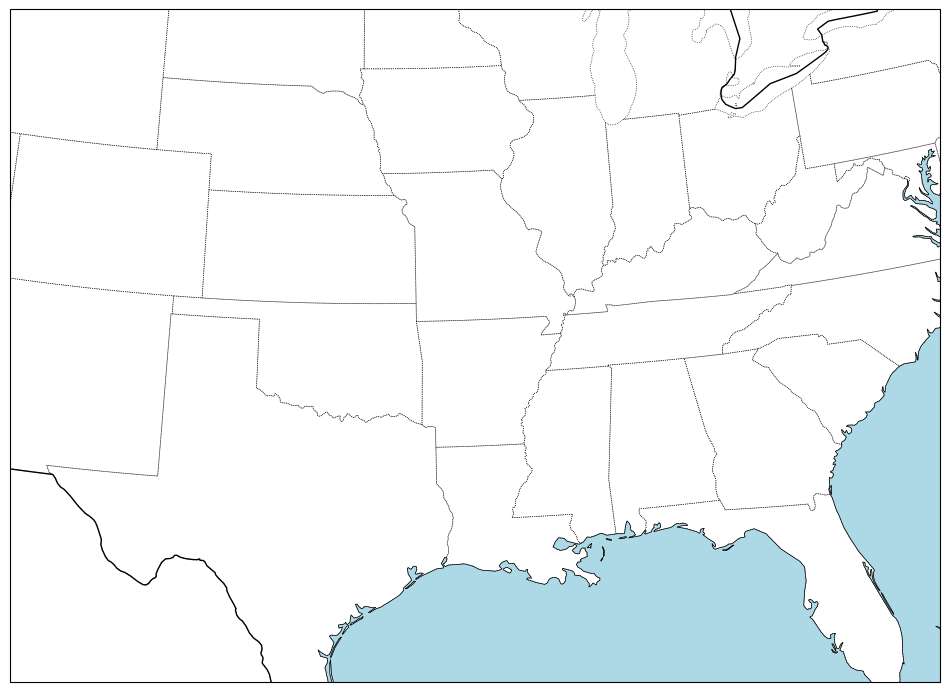

In [19]:
from matplotlib.colors import ListedColormap
custom_cmap = [ #from notebook.community
    "white", # ND
    "darksalmon", # -30
    "coral", # -25
    "tomato", # -20
    "orangered", # -15
    "red", # -10
    "firebrick", # -5
    "maroon", # 0
    ]

realcmap = ListedColormap(custom_cmap, name='nws_reflectivity_colors')

import cartopy.crs as ccrs
import cartopy.feature as cfeature
# Create figure and axes with Cartopy projection
fig, ax = plt.subplots(figsize=(12, 9), subplot_kw={'projection': ccrs.LambertConformal()})

# Set the map extent to focus on the continental US
# Format: [min_longitude, max_longitude, min_latitude, max_latitude]
#ax.set_extent([-125, -66, 25, 50], crs=ccrs.PlateCareee())

# Add geographic features
ax.add_feature(cfeature.LAND, facecolor='white')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=1)
ax.add_feature(cfeature.STATES, linestyle=':', linewidth=0.5)  # Add US state boundaries
ax.set_extent([-107,-79,26,44])
custom_colormap = ax.pcolormesh(ds_file.longitude, ds_file.latitude, refc_5hr_rolling.isel(valid_time=15), cmap = nws_cmap, transform = ccrs.PlateCarree()) #creating the pcolor mesh with the valid_time of 15 with the color map of rainbow and adding longitude and latitude.
plt.colorbar(custom_colormap, ax=ax, label = 'Composite Reflectivity (dB) with NWS Colormap', shrink = 0.8) #creating a colorbar for our map and shrinking it to a respectable size
ax.set_title(f"5 Hour Max Composite Reflectivity in dB\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d} Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=15).values):%HZ %a %b %d}") #setting our title with the model type, initial time, valid time, and what it is plotting
plt.show() #plotting our map

Focus for our threat index: 

Target audience: 

Scale or range chosen for our index: 



In [ ]:
# Importing necessary map plotting modules
import cartopy.crs as ccrs
import cartopy.feature as cfeature
# Creating figure and axes with Cartopy projection
fig, ax = plt.subplots(figsize=(12, 9), subplot_kw={'projection': ccrs.LambertConformal()})

# Research referenced: 
# https://journals.ametsoc.org/view/journals/atsc/79/1/JAS-D-21-0054.1.xml
# https://link.springer.com/chapter/10.1007/978-981-97-0740-9_47

# Adding geographic features and setting the extent of the map
ax.add_feature(cfeature.LAND, facecolor='white')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=1)
ax.add_feature(cfeature.STATES, linestyle=':', linewidth=0.5)  
ax.set_extent([-107,-79,26,44])

# Start with all contributions set to 0. Use rolling time to correct for the biases in short-range models

cape_5hr_rolling = ds_file['cape'].rolling(valid_time=5).max()
cape_5hr_rolling_time = cape_5hr_rolling.isel(valid_time=15).values
cape_contribution = np.zeros_like(cape_5hr_rolling_time)

# Setting the index = 0 if CAPE is less than 1250
mask = (cape_5hr_rolling_time < 1250)
cape_contribution[mask] = 0

# Creating a linearly increasing index from 0 to 1, for CAPE in between 1250 and 2500 (inclusive)
mask = (cape_5hr_rolling_time >= 1250) & (cape_5hr_rolling_time <= 2500)
cape_contribution[mask] = (cape_5hr_rolling_time[mask] - 1250) / 1250

# Setting the index = 1 if CAPE is greater than 2500
mask = cape_5hr_rolling_time > 2500
cape_contribution[mask] = 1

# Plotting the index on the geographical map
cape_index = ax.pcolormesh(ds_file.longitude, ds_file.latitude, cape_contribution, cmap = 'jet', transform=ccrs.PlateCarree())
plt.colorbar(cape_index, ax=ax, label = 'Cape Index', shrink = 0.8) #creating a colorbar for our map and shrinking it to a respectable size

In [ ]:
# Importing necessary map plotting modules
import cartopy.crs as ccrs
import cartopy.feature as cfeature
# Create figure and axes with Cartopy projection
fig, ax = plt.subplots(figsize=(12, 9), subplot_kw={'projection': ccrs.LambertConformal()})
# Research Referenced: https://www.weather.gov/media/wrh/online_publications/TAs/TA1005.pdf

# Add geographic features and setting the extent of the map
ax.add_feature(cfeature.LAND, facecolor='white')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=1)
ax.add_feature(cfeature.STATES, linestyle=':', linewidth=0.5)  
ax.set_extent([-107,-79,26,44])

# Start with all contributions set to 0. Use rolling time to correct for the biases in short-range models
refc_5hr_rolling = ds_file['refc'].rolling(valid_time=5).max()
refc_5hr_rolling_time = refc_5hr_rolling.isel(valid_time=15).values
refc_contribution = np.zeros_like(refc_5hr_rolling_time)

# Setting the index = 0 if reflectivity is less than 45 
mask = refc_5hr_rolling_time < 45
refc_contribution[mask] = 0

# Creating a linearly increasing index from 0 to 1, for reflectivity in betwene 45 and 60 (inclusive)
mask = (refc_5hr_rolling_time >= 45) & (refc_5hr_rolling_time <= 60)
refc_contribution[mask] = ((refc_5hr_rolling_time[mask] - 45) / 15)

# Setting the index = 1 if reflectivty is greater than 60
mask = refc_5hr_rolling_time > 60
refc_contribution[mask] = 1

# Plotting the index on the geographical map
refc_index = ax.pcolormesh(ds_file.longitude, ds_file.latitude, refc_contribution, cmap = 'Reds', transform=ccrs.PlateCarree())
plt.colorbar(refc_index, ax=ax, label = 'Reflectivity Index', shrink = 0.8) #creating a colorbar for our map and shrinking it to a respectable size

In [ ]:
plt.scatter(refc_5hr_rolling_time, refc_contribution)

In [ ]:
plt.scatter(cape_5hr_rolling_time, cape_contribution)

In [1]:
from matplotlib.colors import ListedColormap
custom_cmap = [ #from notebook.community
    "white", # ND
    "darksalmon", # -30
    "coral", # -25
    "tomato", # -20
    "orangered", # -15
    "red", # -10
    "firebrick", # -5
    "maroon", # 0
    ]
realcmap = ListedColormap(custom_cmap, name='nws_reflectivity_colors')
fig, axes = plt.subplots(figsize=(12, 9), subplot_kw={'projection': ccrs.LambertConformal()}) #calling map2 function
pcolor14 = ax.pcolormesh(lon, lat, hail_index(ds_file,15), cmap = realcmap, vmax = 100, transform = dataproj) #creating a pcolormesh map for hail index at step 15
plt.colorbar(pcolor14, ax=axes[0,0], label = 'Hail Index', shrink = 0.7) #creating colorbar for the map
axes[0,0].set_title(f"Hail Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d} Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=15).values):%HZ %a %b %d}") #title for map at step 15 with model name, valid time and initial time


NameError: name 'plt' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import ListedColormap

# Create some example data
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
Z = np.sin(X**2 + Y**2)

# 1️⃣ Get an existing colormap (e.g., 'viridis')
original_cmap = cm.get_cmap('viridis')

# 2️⃣ Convert it to a list of colors
colors = original_cmap(np.linspace(0, 1, 256))

# 3️⃣ Modify the colors — example: make low values white
colors[:50] = [1, 1, 1, 1]  # RGBA for white



In a markdown cell, evaluate your algorithm’s performance:
## Did it produce reasonable values?
Yes, our algorithm produced reasonable values. For the high end case, the algorithm did a commendable job identifying various areas where there were clusters of hail reports. For example, areas such as Central Iowa, Northwestern Illinois, and Southwestern Missouri were all identified by the algorithm as zones with a particularly high hail index, which correlates with a myriad of storm reports in those zones. The algorithm did a good job of identifying the larger area where hail was a possibility - this heightened area extended from Texas to Wisconsin, which is very similar to the broader swath of hail reports seen on the map. As for the lower end case, the hail index algorithm produced realistically small values (which makes sense, given the fact that there were 0 hail reports). The highest (although still very small) values were found near high elevations, which makes sense given the elevated vertical velocity. 
## Were there false alarms or missed threats?
The hail index uses 5-hour rolling time, and the event on April 4, 2023 happened over a far longer duration than 5 hours. Therefore, it struggled to capture some of the convective initiation that occured outside that period. The slightly higher (yet still low) values of the hail index in Pennsylvania, especially, in the low end case is pretty much a false alarm. The only reason the hail index is being slightly activated is because of higher vertical velocity values because of higher elevations. 
## Did you need to revise the formula? If so, how?
We did not need to revise the formula. The above problems do not occur due to the algorithmic merit of our index, but rather unusual features of each day. The high end event occurred over a far longer time period than a usual event. As for vertical velocity issues, we already do not weight it particularly heavily to account for the above issues. We didn't lower its weighting because when it's not an elevation-induced false alarm, it proves to provide a fantastic correlation with hail probability. 

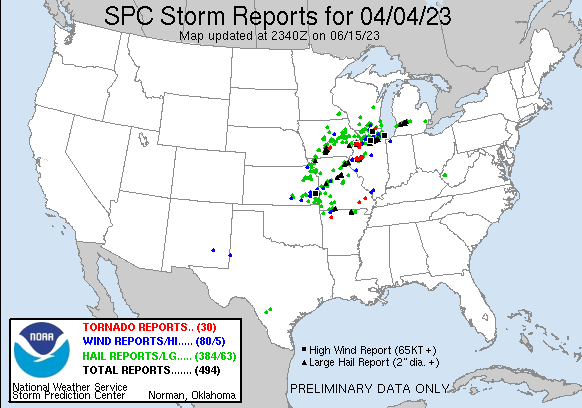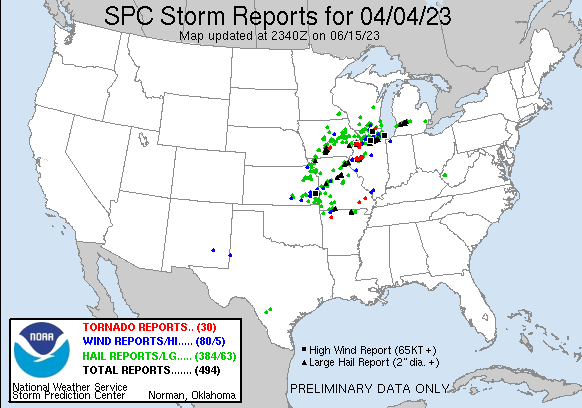